# Geographic Data Visualization with Basemap

## Introduction
Basemap is a powerful toolkit for plotting 2D data on maps in Python. It supports various map projections and provides tools for drawing map backgrounds and plotting geographic data.

In [1]:
!pip install basemap

   ---------------------------------------- 0.0/30.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.5 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.5 MB 2.1 MB/s eta 0:00:15
   - -------------------------------------- 1.3/30.5 MB 2.2 MB/s eta 0:00:14
   -- ------------------------------------- 1.8/30.5 MB 2.3 MB/s eta 0:00:13
   --- ------------------------------------ 2.4/30.5 MB 2.4 MB/s eta 0:00:12
   ---- ----------------------------------- 3.1/30.5 MB 2.6 MB/s eta 0:00:11
   ----- ---------------------------------- 4.2/30.5 MB 2.9 MB/s eta 0:00:10
   ------ --------------------------------- 5.0/30.5 MB 3.1 MB/s eta 0:00:09
   ------- -------------------------------- 5.8/30.5 MB 3.2 MB/s eta 0:00:08
   -------- ------------------------------- 6.8/30.5 MB 3.3 MB/s eta 0:00:08
   ---------- ----------------------------- 7.9/30.5 MB 3.5 MB/s eta 0:00:07
   ------------ --------------------------- 9.2/30.5 MB 3.7 MB/s eta 0:00:06
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albucore 0.0.23 requires opencv-python-headless>=4.9.0.80, which is not installed.
albumentations 2.0.5 requires opencv-python-headless>=4.9.0.80, which is not installed.
deepface 0.0.93 requires opencv-python>=4.5.5.64, which is not installed.
retina-face 0.0.17 requires opencv-python>=3.4.4, which is not installed.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.3.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.



## 1. Map Projections Overview

Map projections transform the Earth's spherical surface onto a flat plane. Basemap supports many projections, including:


### a. Cylindrical Projections
- **Mercator (`'merc'`)**: Preserves angles, distorts area near poles.
- **Cylindrical Equidistant (`'cyl'`)**: Simple, distorts shapes and areas.


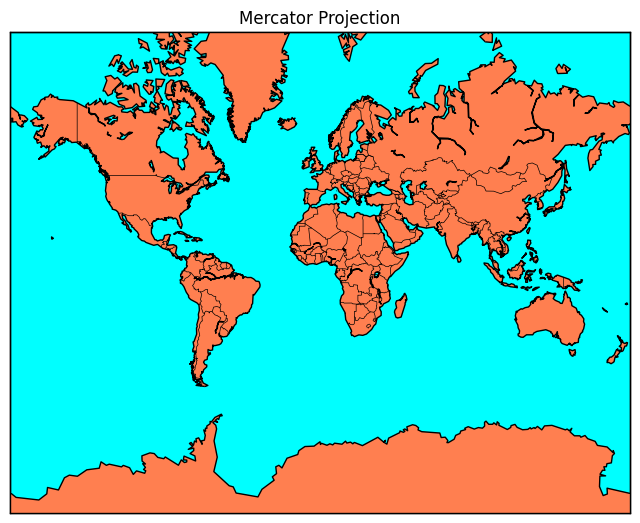

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

plt.figure(figsize=(8, 8))
m = Basemap(projection='merc', llcrnrlat=-80, urcrnrlat=80, llcrnrlon=-180, urcrnrlon=180, lat_ts=20, resolution='c')
m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='coral', lake_colorc='aqua')
m.drawmapboundary(fill_color='aqua')
plt.title("Mercator Projection")
plt.show()

- `projection='merc'`: Sets the map projection to Mercator.
- `llcrnrlat=-80`, `urcrnrlat=80`: Set the latitude of the lower-left and upper-right corners of the map.
- `llcrnrlon=-180`, `urcrnrlon=180`: Set the longitude of the lower-left and upper-right corners of the map.
- `lat_ts=20`: Sets the latitude of true scale.
- `resolution='c'`: Sets the resolution of the coastlines to crude.


### b. Perspective Projections
- **Orthographic (`'ortho'`)**: Simulates view from space, good for global views.
- **Gnomonic (`'gnom'`)**: Projects great circles as straight lines.


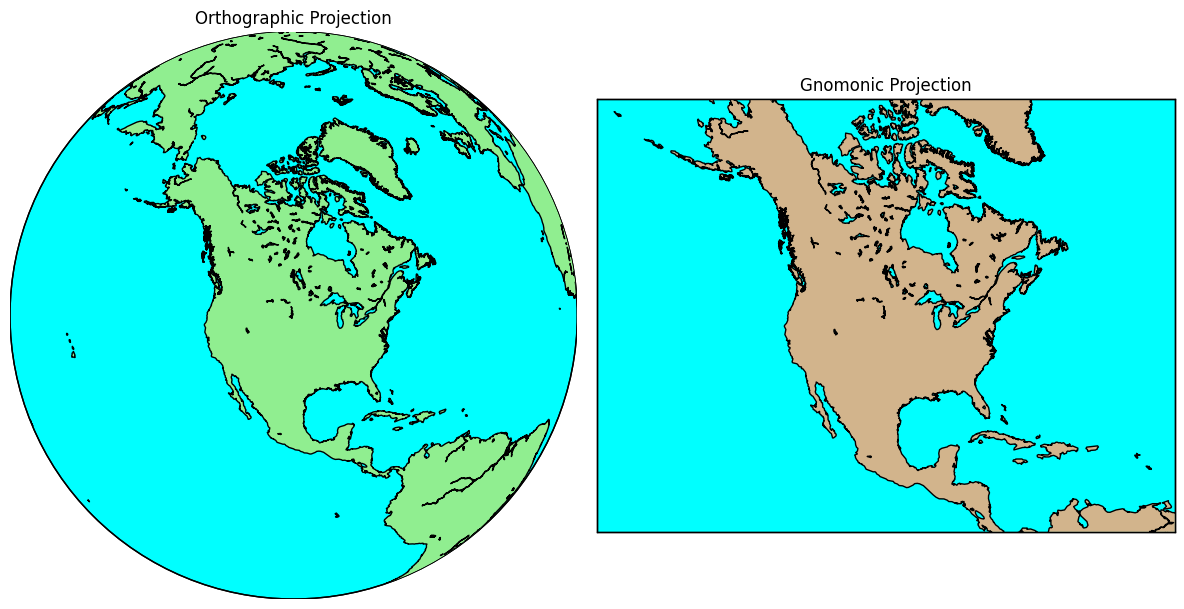

In [3]:
plt.figure(figsize=(12, 6))

# Orthographic Projection
plt.subplot(1, 2, 1)
m_ortho = Basemap(projection='ortho', lat_0=45, lon_0=-100, resolution='l')
m_ortho.drawcoastlines()
m_ortho.fillcontinents(color='lightgreen', lake_color='aqua')
m_ortho.drawmapboundary(fill_color='aqua')
plt.title("Orthographic Projection")

# Gnomonic Projection
plt.subplot(1, 2, 2)
m_gnom = Basemap(projection='gnom', lat_0=45, lon_0=-100, width=12000000, height=9000000, resolution='l')
m_gnom.drawcoastlines()
m_gnom.fillcontinents(color='tan', lake_color='aqua')
m_gnom.drawmapboundary(fill_color='aqua')
plt.title("Gnomonic Projection")

plt.tight_layout()
plt.show()

**Orthographic Projection:**
- `projection='ortho'`: Sets the projection to Orthographic, which shows the Earth as if from space.
- `lat_0=45`, `lon_0=-100`: Sets the center of the projection to 45°N latitude and 100°W longitude.
- `resolution='l'`: Sets the coastline resolution to low.

**Gnomonic Projection:**
- `projection='gnom'`: Sets the projection to Gnomonic, where great circles are shown as straight lines.
- `lat_0=45`, `lon_0=-100`: Centers the map on 45°N latitude and 100°W longitude.
- `width=12000000`, `height=9000000`: Specifies the width and height of the map in meters.


### c. Conic Projections
- **Lambert Conformal Conic (`'lcc'`)**: Preserves angles, used for mid-latitude regions.
- **Albers Equal Area (`'aea'`)**: Preserves area, suitable for large countries.

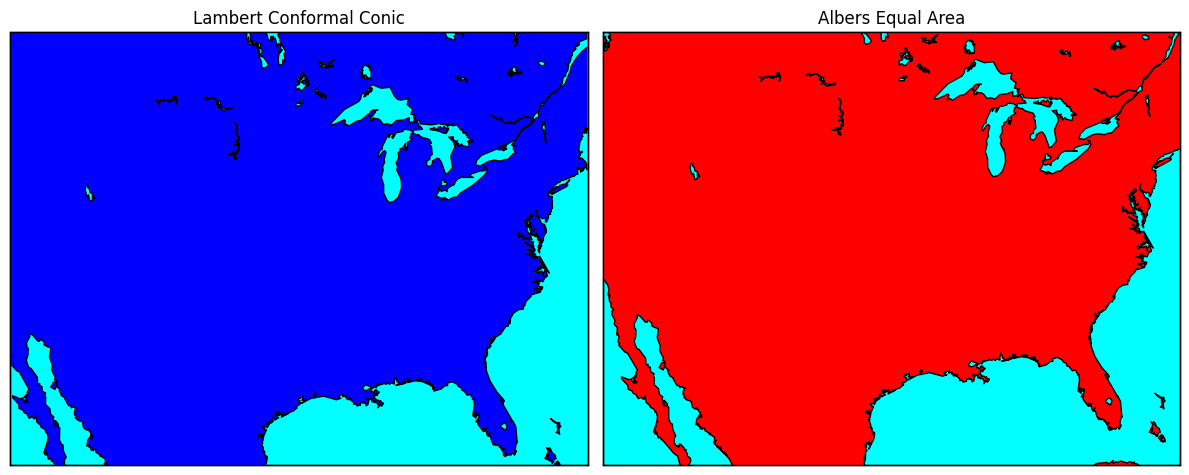

In [4]:
plt.figure(figsize=(12, 6))

# Lambert Conformal Conic Projection
plt.subplot(1, 2, 1)
m_lcc = Basemap(projection='lcc', lat_1=33, lat_2=45, lon_0=-95, lat_0=39, width=4000000, height=3000000, resolution='l')
m_lcc.drawcoastlines()
m_lcc.fillcontinents(color='blue', lake_color='aqua')
m_lcc.drawmapboundary(fill_color='aqua')
plt.title("Lambert Conformal Conic")

# Albers Equal Area Projection
plt.subplot(1, 2, 2)
m_aea = Basemap(projection='aea', lat_1=29.5, lat_2=45.5, lon_0=-96, lat_0=37.5, width=4000000, height=3000000, resolution='l')
m_aea.drawcoastlines()
m_aea.fillcontinents(color='red', lake_color='aqua')
m_aea.drawmapboundary(fill_color='aqua')
plt.title("Albers Equal Area")

plt.tight_layout()
plt.show()

**Lambert Conformal Conic Projection:**
- `projection='lcc'`: Sets the projection to Lambert Conformal Conic, which is good for mid-latitude areas.
- `lat_1=33`, `lat_2=45`: Sets the two standard parallels where the scale is true.
- `lon_0=-95`, `lat_0=39`: Defines the center of the projection.
- `width=4000000`, `height=3000000`: Sets the width and height of the map in meters.

**Albers Equal Area Projection:**
- `projection='aea'`: Sets the projection to Albers Equal Area, which preserves the area of features.
- `lat_1=29.5`, `lat_2=45.5`: Sets the two standard parallels.
- `lon_0=-96`, `lat_0=37.5`: Defines the center of the projection.


## 2. Drawing a Map Background


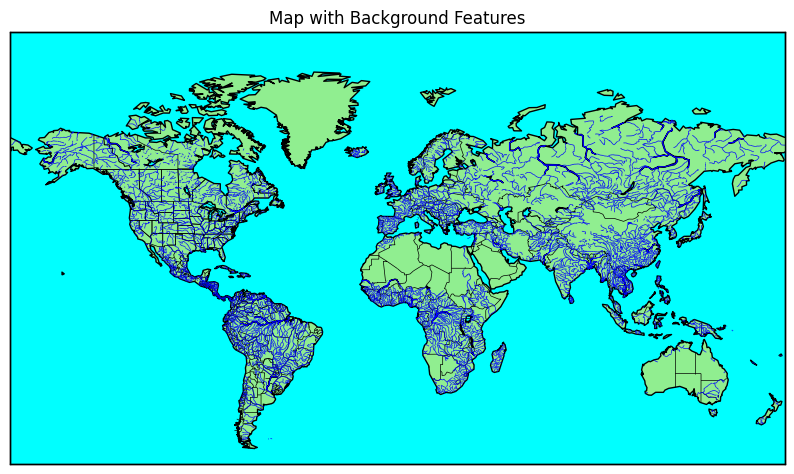

In [5]:
plt.figure(figsize=(10, 8))
m = Basemap(projection='mill', llcrnrlat=-60, urcrnrlat=90, llcrnrlon=-180, urcrnrlon=180, resolution='c')

# Draw coastlines, countries, and states
m.drawcoastlines()
m.drawcountries()
m.drawstates()

# Draw rivers
m.drawrivers(color='blue')

# Fill continents and draw map boundary
m.fillcontinents(color='lightgreen', lake_color='aqua')
m.drawmapboundary(fill_color='aqua')

plt.title("Map with Background Features")
plt.show()

- `projection='mill'`: Sets the map projection to Miller Cylindrical.
- `llcrnrlat=-60`, `urcrnrlat=90`: Sets the lower-left and upper-right corner latitudes.
- `llcrnrlon=-180`, `urcrnrlon=180`: Sets the lower-left and upper-right corner longitudes.
- `m.drawstates()`: Draws state boundaries.
- `m.drawrivers()`: Draws major rivers.

## 3. Plotting data on Maps

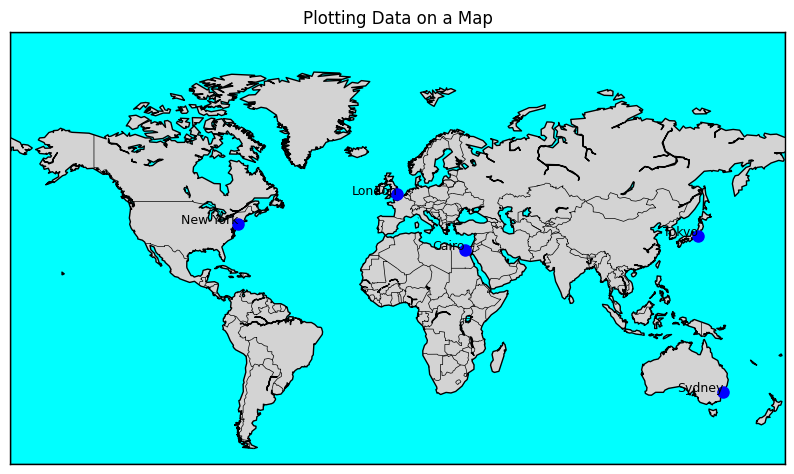

In [6]:
import numpy as np

# Create a map
plt.figure(figsize=(10, 8))
m = Basemap(projection='mill', llcrnrlat=-60, urcrnrlat=90, llcrnrlon=-180, urcrnrlon=180, resolution='c')
m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray', lake_color='aqua')
m.drawmapboundary(fill_color='aqua')

# Sample data: cities and their coordinates
cities = {
    'New York': (-74.0060, 40.7128),
    'London': (-0.1278, 51.5074),
    'Tokyo': (139.6917, 35.6895),
    'Sydney': (151.2093, -33.8688),
    'Cairo': (31.2357, 30.0444)
}

# Plotting each city
for city, coords in cities.items():
    lon, lat = coords
    x, y = m(lon, lat)
    m.plot(x, y, 'bo', markersize=8)
    plt.text(x, y, city, fontsize=9, ha='right')

plt.title("Plotting Data on a Map")
plt.show()

- `m(lon, lat)`: This function call converts the longitude and latitude coordinates of a city into the map's x and y coordinates.
- `m.plot(x, y, 'bo', markersize=8)`: Plots a blue circular marker ('bo') at the calculated (x, y) position on the map.
- `plt.text(x, y, city, ...)`: Adds the city's name as a text label near its plotted point.